<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/DL/day12_ann_optimization_mnist_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(X_train, y_train), (X_test, y_test) = (
    tf.keras.datasets.mnist.load_data()
)
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


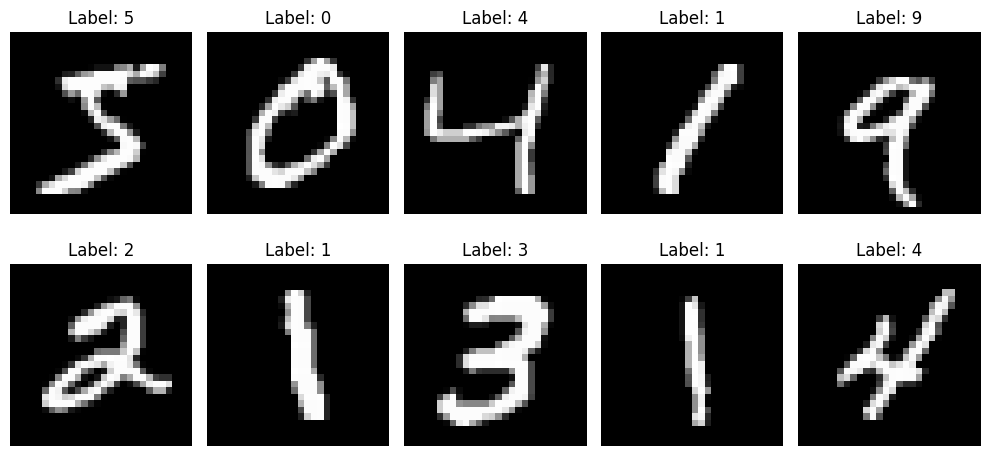

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [5]:
def build_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])
    return model

In [6]:
model = build_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9222 - loss: 0.2687 - val_accuracy: 0.9574 - val_loss: 0.1412
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9652 - loss: 0.1135 - val_accuracy: 0.9676 - val_loss: 0.1089
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9762 - loss: 0.0766 - val_accuracy: 0.9718 - val_loss: 0.0914
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9815 - loss: 0.0599 - val_accuracy: 0.9723 - val_loss: 0.0949
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9853 - loss: 0.0456 - val_accuracy: 0.9737 - val_loss: 0.0899
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9884 - loss: 0.0366 - val_accuracy: 0.9707 - val_loss: 0.1047
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9909 - loss: 0.0279 - val_accuracy: 0.9726 - val_loss: 0.1057
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9916 - loss: 0.02

In [7]:
learning_rates = [0.1, 0.01, 0.001]
results = {}
for lr in learning_rates:
    model = build_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_lr = model.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    results[lr] = history_lr.history["val_accuracy"][-1]
    print("Learning rate:", lr,
          "Validation accuracy:", round(results[lr], 4))

Learning rate: 0.1 Validation accuracy: 0.1079
Learning rate: 0.01 Validation accuracy: 0.955
Learning rate: 0.001 Validation accuracy: 0.9719


In [8]:
batch_sizes = [16, 32, 64]
batch_results = {}
for batch in batch_sizes:
    model = build_model()
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_batch = model.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=batch,
        validation_split=0.2,
        verbose=0
    )
    batch_results[batch] = history_batch.history["val_accuracy"][-1]
    print("Batch size:", batch,
          "Validation accuracy:", round(batch_results[batch], 4))

Batch size: 16 Validation accuracy: 0.9705
Batch size: 32 Validation accuracy: 0.9688
Batch size: 64 Validation accuracy: 0.9639


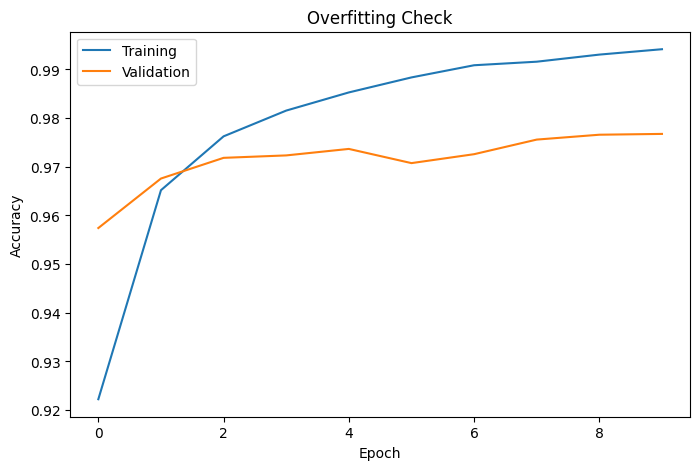

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overfitting Check")
plt.legend()
plt.show()

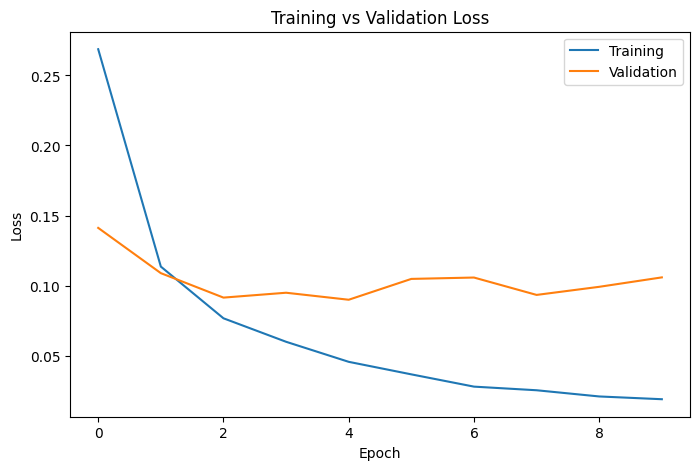

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [12]:
dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])
dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
dropout_history = dropout_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.8769 - loss: 0.4044 - val_accuracy: 0.9531 - val_loss: 0.1573
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9413 - loss: 0.1977 - val_accuracy: 0.9643 - val_loss: 0.1216
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9537 - loss: 0.1561 - val_accuracy: 0.9689 - val_loss: 0.1056
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9599 - loss: 0.1330 - val_accuracy: 0.9726 - val_loss: 0.1020
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9641 - loss: 0.1174 - val_accuracy: 0.9729 - val_loss: 0.0924
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9670 - loss: 0.1077 - val_accuracy: 0.9714 - val_loss: 0.0997
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9691 - loss: 0.0990 - val_accuracy: 0.9737 - val_loss: 0.0908
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9707 - loss: 0.0

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
dropout_history = dropout_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9752 - loss: 0.0794 - val_accuracy: 0.9764 - val_loss: 0.0928
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9772 - loss: 0.0740 - val_accuracy: 0.9765 - val_loss: 0.0900
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9772 - loss: 0.0725 - val_accuracy: 0.9763 - val_loss: 0.0900
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9778 - loss: 0.0691 - val_accuracy: 0.9762 - val_loss: 0.0937


In [15]:
test_loss, test_accuracy = dropout_model.evaluate(
    X_test, y_test, verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Loss: 0.07694995403289795
Test Accuracy: 97.59 %


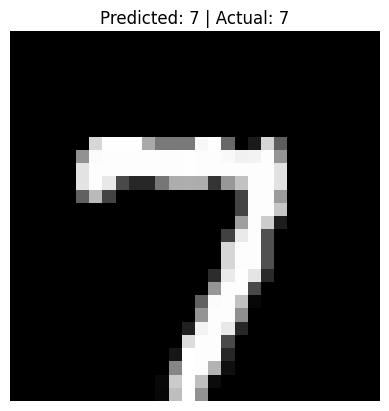

In [16]:
index = np.random.randint(0, len(X_test))

image = X_test[index]
prediction = dropout_model.predict(
    image.reshape(1, 28, 28),
    verbose=0
)

predicted_digit = np.argmax(prediction[0])

plt.imshow(image, cmap="gray")
plt.title(
    f"Predicted: {predicted_digit} | Actual: {y_test[index]}"
)
plt.axis("off")
plt.show()